In [124]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

Read the data (column 5 are labels)

In [125]:
data=np.genfromtxt('galaxyquasar.csv', delimiter=',',names=True,usecols=(0,1,2,3,4,6),dtype=float,comments='#')
names = data.dtype.names
names

('u', 'g', 'r', 'i', 'z', 'z1')

In [126]:
#data without header and labels
data=np.genfromtxt('galaxyquasar.csv', delimiter=',',skip_header=1,usecols=(0,1,2,3,4,6),dtype=float)

In [127]:
#column 5 are labels
lab=np.genfromtxt('galaxyquasar.csv', delimiter=',',skip_header=1,usecols=5,dtype=str)
lab

array(['QSO', 'GALAXY', 'GALAXY', ..., 'GALAXY', 'GALAXY', 'GALAXY'],
      dtype='<U6')

Build the colors

In [128]:
d = dict(zip(names, data.T))  #create a dictionary 

for diff in ['ug', 'gr', 'ri', 'iz']:
    d[diff]=d[diff[0]]-d[diff[1]] 
d['lab']=lab
d.keys()

X=np.array([d['ug'], d['gr'], d['ri'], d['iz']]).T              #array of color 
labels = np.where(lab == "QSO", 0, 1)                        #0 for quasar, 1 for galaxy
print(labels)

[0 1 1 ... 1 1 1]


In [129]:
import sklearn.model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier


In [162]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, labels, test_size=0.33, random_state=67)
X_train.shape

(33500, 4)

### Naive Bayes and Quadratic Discriminant Analysis

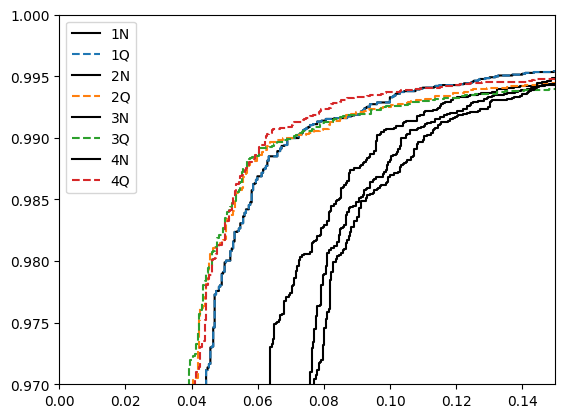

In [131]:
clf1 = GaussianNB()                  #classifier
clf2 = QuadraticDiscriminantAnalysis()


for i in range(4):                          #adding more and more faetures 

    clf1.fit(X_train[:,0:i+1] ,y_train)
    clf2.fit(X_train[:,0:i+1] ,y_train)

    y_prob1 = clf1.predict_proba(X_test[:,0:i+1])  [:,1]          #probability of belonging to the second class
    y_prob2 = clf2.predict_proba(X_test[:,0:i+1])  [:,1]

    fpr1, tpr1, thresh1 = roc_curve(y_test, y_prob1)            #false positive rate, true positive rate, thresholds
    fpr2, tpr2, thresh2 = roc_curve(y_test, y_prob2)
    plt.plot(fpr1, tpr1, label=str(i+1)+"N", c='black')  #plotting ROC curve
    plt.plot(fpr2, tpr2, label=str(i+1)+"Q", linestyle='--')

plt.xlim(0,0.15)
plt.ylim(0.97,1)
plt.legend();

Naive bayes seems to work better with only one feature (maybe it is because they are not independent!).


Insted we notice that for QDA the performance is better with more features and with 4 feature it performs better. 

### GMM Bayes

(0.9, 1.0)

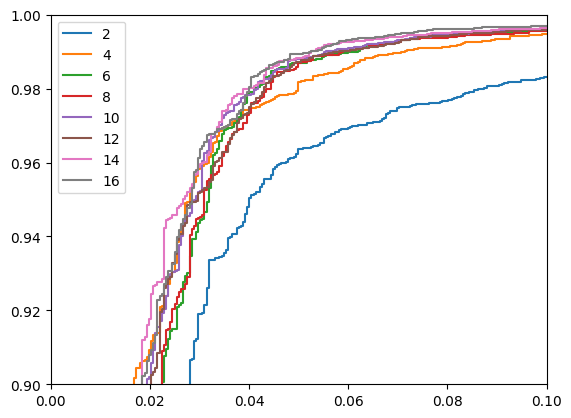

In [132]:
for n in np.arange(2,18)[::2]:                  #incresing the number of gaussians 
    
    clf = GMMBayes(n_components=n)
    clf.fit(X_train,y_train)
    
    y_prob = clf.predict_proba(X_test) [:,1] 
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(n))

plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)

### Actually Classify with GMM Bayes, with n=16 components

In [ ]:
clf = GMMBayes(n_components=16)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

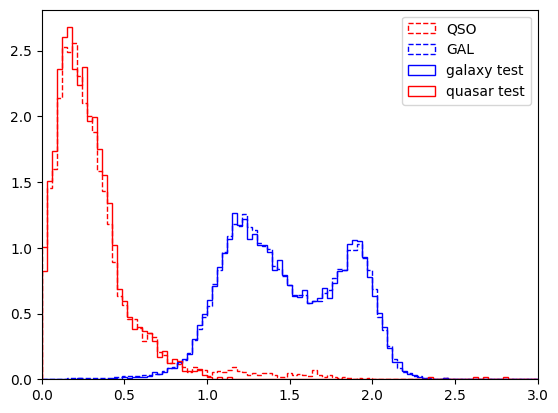

In [134]:
d_test = dict(zip(names, X_test.T))  #create a dictionary for test data

plt.hist(d['ug'][lab=='QSO'],histtype='step',bins=np.linspace(0,3,100), color='red', label='QSO', density=True, linestyle='--')
plt.hist(d['ug'][lab=='GALAXY'],histtype='step',bins=np.linspace(0,3,100), color='blue', linestyle='--', label='GAL', density= True)    
plt.hist(X_test[:,0][y_pred==1],histtype='step',bins=np.linspace(0,3,100), label='galaxy test', density=True, color='blue')
plt.hist(X_test[:,0][y_pred==0],histtype='step',bins=np.linspace(0,3,100), label='quasar test', density=True, color='red')
plt.legend()
plt.xlim(0,3);


It is possible to see some contamination of quasar in galaxies

In [136]:
from astroML.utils import completeness_contamination

accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.3f}")  # 3 decimali


completeness, contamination = completeness_contamination(y_pred, y_test)
print(f"Completeness: {completeness:.3f}")
print(f"Contamination: {contamination:.3f}")

print(f"Size of the test sample: {len(y_test)}")

# False quasars
false_quasars = np.sum((y_pred == 0) & (y_test == 1))
false_quasar_rate = false_quasars / len(y_test)
print(f"Number of false quasars: {false_quasars}")
print(f"False quasars rate: {false_quasar_rate:.3f}")

Accuracy: 0.985
Completeness: 0.993
Contamination: 0.010
Size of the test sample: 16500
Number of false quasars: 100
False quasars rate: 0.006


# LAST LECTURE 

### DECISION TREE

(0.9, 1.0)

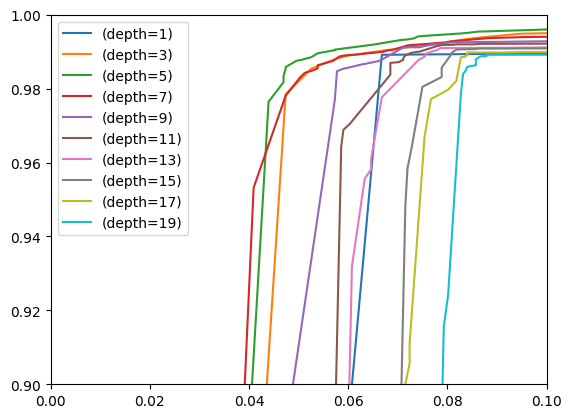

In [183]:
from sklearn.tree import DecisionTreeClassifier

completeness_test = []
contamination_test = []
completeness_train = []
contamination_train = []

md_vals = np.arange(1,20,2)
for md in md_vals:
    clf = DecisionTreeClassifier(random_state=42, max_depth=md,criterion='gini')
    clf.fit(X_train, y_train)

    y_prob = clf.predict_proba(X_test) [:,1] 
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'(depth={md})')

plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)


The best seems to be max_depth = 5.

Is it overfitting?

In [185]:
best_md = 5  # Best depth found from previous runs
clf = DecisionTreeClassifier(random_state=42, max_depth=best_md,criterion='gini')
clf.fit(X_train, y_train)

y_pred_test = clf.predict(X_test)
C = sklearn.metrics.confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = C.ravel()
completeness_test=(tp/(tp+fn))
contamination_test=(fp/(tp+fp))

y_pred = clf.predict(X_train)
C = sklearn.metrics.confusion_matrix(y_train, y_pred)
tn, fp, fn, tp = C.ravel()
completeness_train=(tp/(tp+fn))
contamination_train=(fp/(tp+fp))

print("completeness test", completeness_test)
print("contamination test", contamination_test)
print("completeness train", completeness_train)
print("contamination train", contamination_train)
print("Accuracy test", np.mean(y_pred_test == y_test))

completeness test 0.9931588969602934
contamination test 0.011512003369366839
completeness train 0.9942482657649806
contamination train 0.009893428680529039
Accuracy test 0.9841818181818182


###  DEEP LEARNING 

It is important normalized data first

In [189]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#Standardized data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [188]:
#Base model
mlp = MLPClassifier(hidden_layer_sizes=(5,), activation='relu', solver='adam',
                    alpha=0, max_iter=500, random_state=42)

# Pipeline: scaling + modello
pipe = Pipeline([
    ('scaler', scaler),
    ('mlp', mlp)
])

# Griglia di valori per il learning rate
param_grid = {
    'mlp__learning_rate_init': [0.0001, 0.001, 0.01, 0.1]
}

# GridSearchCV
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('mlp',
                                        MLPClassifier(alpha=0,
                                                      hidden_layer_sizes=(5,),
                                                      max_iter=500,
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'mlp__learning_rate_init': [0.0001, 0.001, 0.01, 0.1]},
             scoring='accuracy')

In [191]:
print("Best Classifier found:")
print(grid.best_params_)

test_accuracy = grid.score(X_test_scaled, y_test)
print(f"Accurancy on the test: {test_accuracy:.3f}")


Best Classifier found:
{'mlp__learning_rate_init': 0.01}
Accurancy on the test: 0.984


### COMPARISON: comparison the best classifier done

(0.9, 1.0)

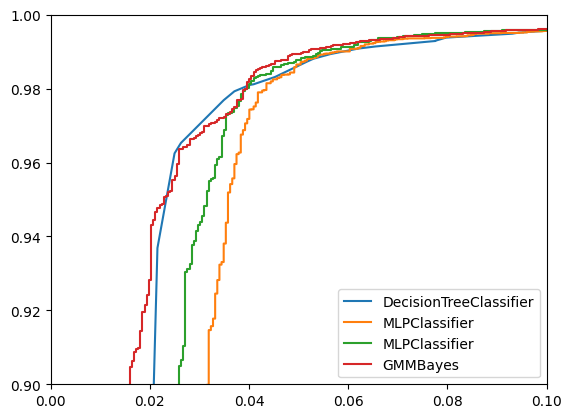

In [192]:
Classifier=[DecisionTreeClassifier(random_state=0, max_depth=best_md,criterion='entropy'),
            sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(6), activation='relu', solver='adam', alpha=0, learning_rate_init=0.001, max_iter=500),
            sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(5), activation='relu', solver='adam', alpha=0, learning_rate_init=0.01, max_iter=500),
            GMMBayes(n_components=16)]

for i in range(len(Classifier)):              
    
    clf = Classifier[i]
    clf.fit(X_train,y_train)
    
    y_prob = clf.predict_proba(X_test) [:,1] 
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(clf).split('(')[0])

plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)